# Demo

In [ ]:
import numpy as np
from lucifex.fdm import AB, CN
from lucifex.sim import run, xdmf_to_npz, GridSimulation
from lucifex.viz import (
    plot_colormap, create_animation, plot_line, save_figure, 
    display_animation, get_ipynb_file_name,
)
from lucifex.solver import OptionsPETSc
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE, critical_sr
from crocodil.dns import threshold_rayleigh

STORE = 1
WRITE = None
DIR_BASE = f'./{get_ipynb_file_name()}'
DIR_PARAMS = (*SYSTEM_A_REFERENCE.keys(), 'Nx', 'Ny')
NX = 60
NY = 60

simulation = dns_system_a(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_base=DIR_BASE, 
    dir_params=DIR_PARAMS,
)(
    Nx=NX,
    Ny=NY,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    D_adv=AB(1)@CN, 
    D_diff=AB(1)@CN,
    dt_max=0.1,
    courant_adv=0.75,
    flow_petsc=(OptionsPETSc('cg', 'hypre'), None),
    diagnostic=True,
)

t_stop = 20.0
n_stop = 10
dt_init = 1e-6
n_init = 6
run(simulation, t_stop=t_stop, n_stop=n_stop, dt_init=dt_init, n_init=n_init)
if WRITE:
    xdmf_to_npz(simulation, delete_xdmf=False)

s, c, u, psi = simulation['s', 'c', 'u', 'psi']


grid_sim = GridSimulation.from_simulation(
    simulation
)

Di Ki Bu


: 

In [2]:
Lx, Ly = simulation['Lx', 'Ly']
Ra_crit = threshold_rayleigh(Lx, Ly, NX, 2)
print(f"Ra = {SYSTEM_A_REFERENCE['Ra']} , Ra_thresh = {Ra_crit}")

Ra = 1000.0 , Ra_thresh = 1350.0


In [3]:
zeta0, sr, cr, epsilon = SYSTEM_A_REFERENCE['zeta0', 'sr', 'cr', 'epsilon']
sr_crit = critical_sr(zeta0, cr, epsilon)
print(f'sr_crit = {sr_crit} , sr = {sr}')

sr_crit = 0.10000000000000002 , sr = 0.2


In [ ]:
time_slice = slice(0, None, 2)
titles = [f'${c.name}(t={t:.3f})$' for t in c.time_series[time_slice]]

anim = create_animation(
    plot_colormap,
    colorbar=False,
)(c.series[time_slice], title=titles)
anim_path = save_figure(f'{c.name}(t)', simulation.dir_path, get_path=True)(anim)

display_animation(anim_path)

In [ ]:
time_slice = slice(0, None, 2)
titles = [f'${s.name}(t={t:.3f})$' for t in s.time_series[time_slice]]

anim = create_animation(
    plot_colormap,
    colorbar=(0, sr),
    y_lims=(SYSTEM_A_REFERENCE['zeta0'], 1.0),
    aspect='auto',
)(s.series[time_slice], title=titles)
anim_path = save_figure(f'{s.name}(t)', simulation.dir_path, get_path=True)(anim)

display_animation(anim_path)

In [ ]:
f = simulation['f']
f, fPlus, fMinus = f.split()

fig, ax = plot_line(
    [(f.time_series, [np.sum(i) for i in f.value_series]), (f.time_series, f.value_series)],
    cyc='black',
    x_label='$t$',
    legend_labels=['$F$', '$F_{\mathbf{u}}$', '$F_{\mathsf{D}}$'],
    legend_title='$y=h_0$',
)
save_figure('f(y=h0,t)', simulation.dir_path, prefix_ipynb=False)(fig)

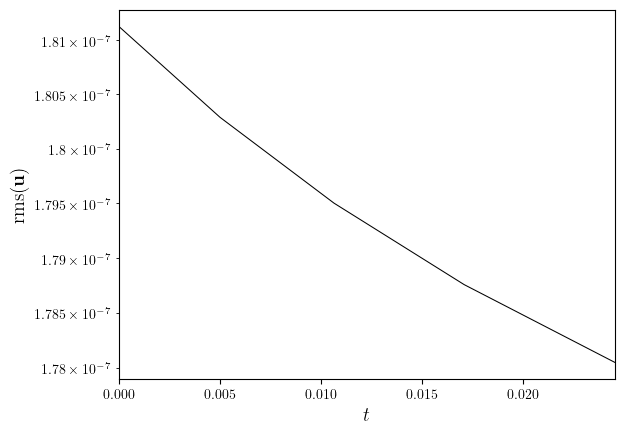

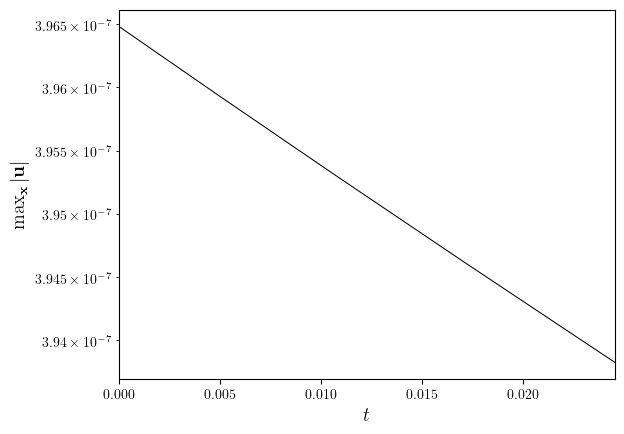

: 

In [ ]:
uRMS, uMinMax = simulation['uRMS', 'uMinMax']
uMax = uMinMax.sub(1)

fig, ax = plot_line(
    (uRMS.time_series, uRMS.value_series),
    x_label='$t$',
    y_label='$\mathrm{rms}(\mathbf{u})$',
)
ax.set_yscale('log')
save_figure('uRMS(t)', simulation.dir_path, prefix_ipynb=False)(fig)

fig, ax = plot_line(
    (uMax.time_series, uMax.value_series),
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
)
ax.set_yscale('log')
save_figure('uMax(t)', simulation.dir_path)(fig)

In [ ]:
mC, mD = simulation['mC', 'mD']

fig, ax = plot_line(
    (mC.time_series, mC.value_series),
    x_label='$t$',
    y_label='$m_C$',
)
save_figure('mC(t)', simulation.dir_path)(fig)

fig, ax = plot_line(
    (mD.time_series, mD.value_series),
    x_label='$t$',
    y_label='$m_D$'
)
save_figure('mD(t)', simulation.dir_path)(fig)

fig, ax = plot_line(
    (mC.time_series, [i + j for i, j in zip(mC.value_series, mD.value_series)]),
    x_label='$t$',
    y_label='$m$'
)
save_figure('m(t)', simulation.dir_path)(fig)

In [ ]:
cMinMax = simulation['cMinMax']
cMin, cMax = cMinMax.split()

fig, ax = plot_line(
    (cMax.time_series, cMax.value_series),
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}(c)$',
    y_lims=(1-0.1, 1+0.1),
)
save_figure('cMax(t)', simulation.dir_path)(fig)

fig, ax = plot_line(
    (cMin.time_series, cMin.value_series),
    x_label='$t$',
    y_label='$\min_{\mathbf{x}}(c)$',
)
save_figure('cMin(t)', simulation.dir_path)(fig)

if 'cCorr' in simulation.namespace:
    cCorr = simulation['cCorr']
    fig, ax = plot_line(
        (cCorr.time_series, [np.max(np.abs(i)) for i in cCorr.dofs_series]),
        x_label='$t$',
        y_label='$\max_{\mathbf{x}}|\mathcal{C}(c)|$',
    )
    ax.set_yscale('log')
    save_figure('cCorrMax(t)', simulation.dir_path)(fig)

In [ ]:
dt, dtU, dtD, dtSigma = simulation['dt', 'dtU', 'dtD', 'dtSigma']

fig, ax = plot_line(
    [
        (dt.time_series, dt.value_series), 
        (dtU.time_series, dtU.value_series), 
        (dtD.time_series, dtD.value_series), 
        (dtSigma.time_series, dtSigma.value_series),
    ],
    x_label='$t$',
    legend_labels=['$\Delta t$', '$\Delta t_{\mathbf{u}}$', '$\Delta t_{\mathsf{D}}$', '$\Delta t_{\Sigma}$'],
)
ax.set_yscale('log')
save_figure('dt(t)', simulation.dir_path, prefix_ipynb=False)(fig)